# Lab 04 – Tiền xử lý dữ liệu (House Prices – Ames, Iowa)
Notebook phần **Tiền xử lý dữ liệu**. Chạy lần lượt từ trên xuống. Ảnh lưu ở `figures/`, dữ liệu sau xử lý lưu ở `processed/`.

## 1. Nạp dữ liệu & khám phá ban đầu (Hình 1)

Train: (1460, 81) | Test: (1459, 80)

Kiểu dữ liệu:
 str        43
int64      35
float64     3
Name: count, dtype: int64

Số dòng trùng lặp: 0

Số cột có giá trị thiếu: 19
              So_NaN  Ty_le_%
PoolQC          1453    99.52
MiscFeature     1406    96.30
Alley           1369    93.77
Fence           1179    80.75
MasVnrType       872    59.73
FireplaceQu      690    47.26
LotFrontage      259    17.74
GarageType        81     5.55
GarageYrBlt       81     5.55
GarageFinish      81     5.55
GarageQual        81     5.55
GarageCond        81     5.55
BsmtExposure      38     2.60
BsmtFinType2      38     2.60
BsmtQual          37     2.53
BsmtCond          37     2.53
BsmtFinType1      37     2.53
MasVnrArea         8     0.55
Electrical         1     0.07


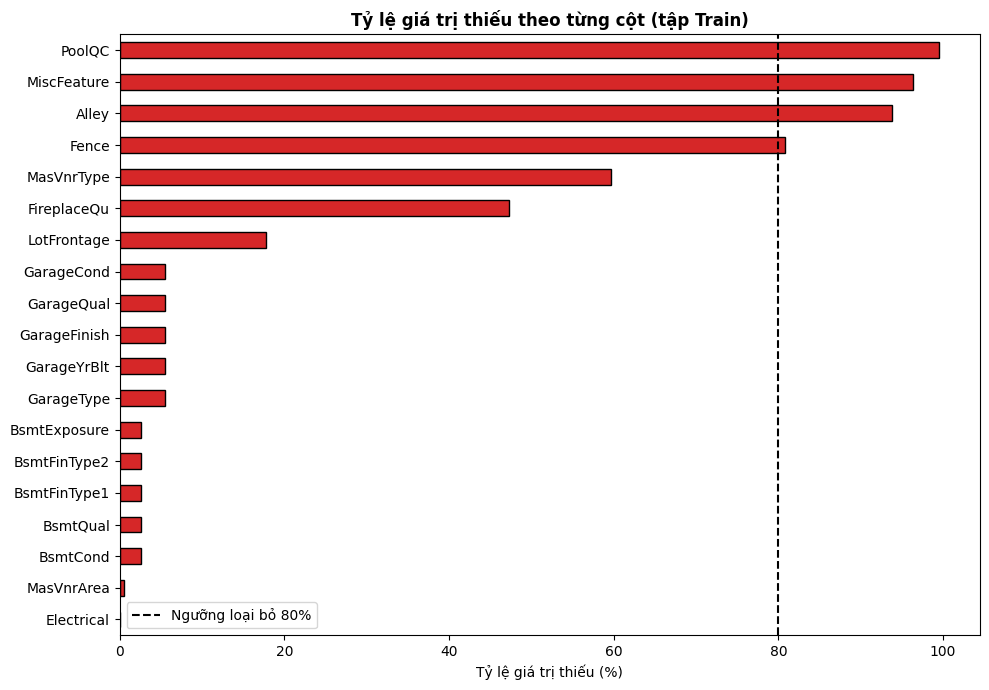

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True); os.makedirs("processed", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"figures/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

def find_data_file(filename):
    for p in [filename, os.path.join("..", filename),
              os.path.join("/kaggle/input/house-prices-advanced-regression-techniques", filename)]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Không thấy {filename}. Hãy đặt file vào thư mục chứa notebook: {os.getcwd()}")

train_file = find_data_file("train.csv")
test_file  = find_data_file("test.csv")

df = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)
print("Train:", df.shape, "| Test:", df_test.shape)
print("\nKiểu dữ liệu:\n", df.dtypes.value_counts())
print("\nSố dòng trùng lặp:", df.duplicated().sum())

miss = (df.isna().mean() * 100)
miss = miss[miss > 0].sort_values(ascending=False)
print(f"\nSố cột có giá trị thiếu: {len(miss)}")
print(pd.DataFrame({"So_NaN": df[miss.index].isna().sum(), "Ty_le_%": miss.round(2)}))

plt.figure(figsize=(10, 7))
miss.sort_values().plot.barh(color="#d62728", edgecolor="black")
plt.axvline(80, color="black", linestyle="--", label="Ngưỡng loại bỏ 80%")
plt.xlabel("Tỷ lệ giá trị thiếu (%)")
plt.title("Tỷ lệ giá trị thiếu theo từng cột (tập Train)", fontweight="bold")
plt.legend(); save("hinh1_missing")

## 2. Biến mục tiêu SalePrice: trước và sau log1p (Hình 2)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
NaN: 0 | Âm: 0
Skew gốc: 1.8829
Skew sau log1p: 0.1213


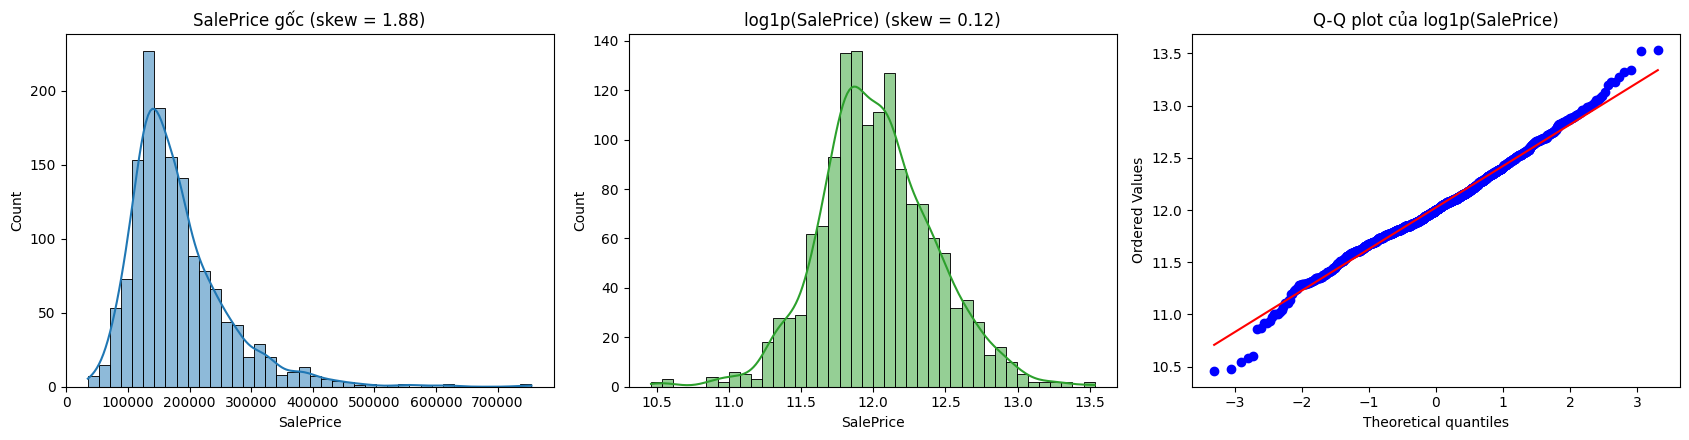

In [2]:
from scipy import stats
print(df["SalePrice"].describe())
print("NaN:", df["SalePrice"].isna().sum(), "| Âm:", (df["SalePrice"] < 0).sum())
print("Skew gốc:", round(df["SalePrice"].skew(), 4))
print("Skew sau log1p:", round(np.log1p(df["SalePrice"]).skew(), 4))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(df["SalePrice"], kde=True, bins=40, ax=ax[0], color="#1f77b4")
ax[0].set_title(f"SalePrice gốc (skew = {df['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, bins=40, ax=ax[1], color="#2ca02c")
ax[1].set_title(f"log1p(SalePrice) (skew = {np.log1p(df['SalePrice']).skew():.2f})")
stats.probplot(np.log1p(df["SalePrice"]), plot=ax[2]); ax[2].set_title("Q-Q plot của log1p(SalePrice)")
save("hinh2_target")

## 3. Tương quan với SalePrice (Hình 3)

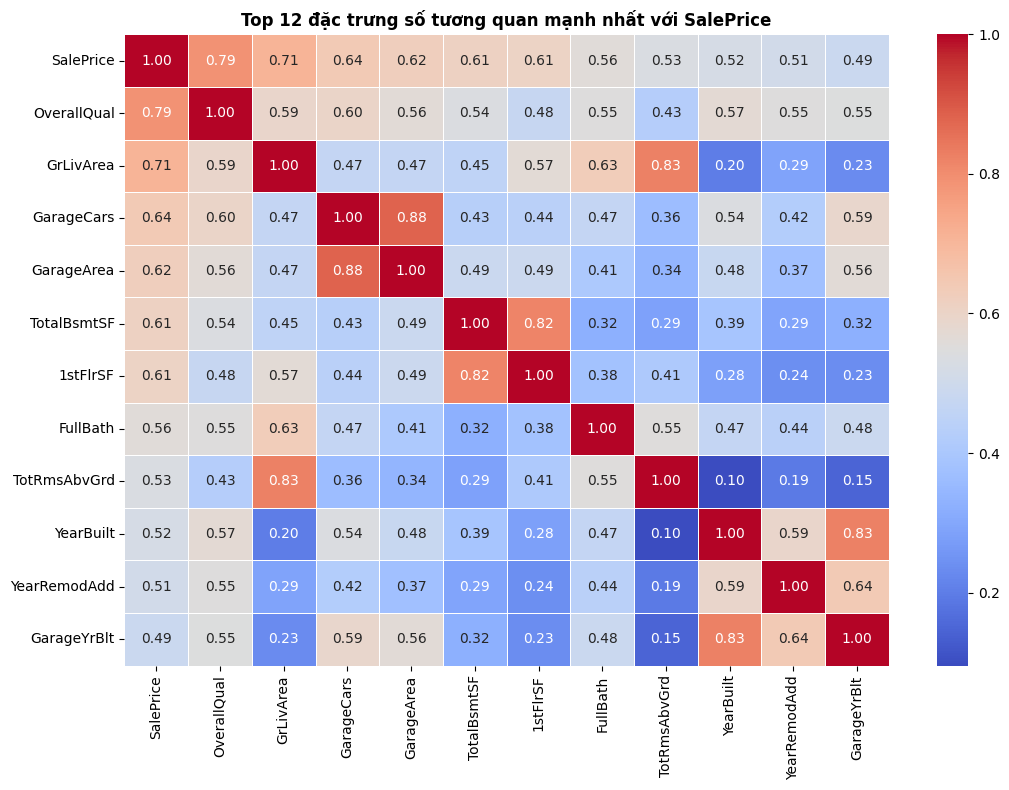

OverallQual     0.7910
GrLivArea       0.7086
GarageCars      0.6404
GarageArea      0.6234
TotalBsmtSF     0.6136
1stFlrSF        0.6059
FullBath        0.5607
TotRmsAbvGrd    0.5337
YearBuilt       0.5229
YearRemodAdd    0.5071
Name: SalePrice, dtype: float64


In [3]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
top = corr["SalePrice"].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(11, 8))
sns.heatmap(num_df[top].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title("Top 12 đặc trưng số tương quan mạnh nhất với SalePrice", fontweight="bold")
save("hinh3_corr")
print(corr["SalePrice"].drop("SalePrice").sort_values(ascending=False).head(10).round(4))

## 4. Xử lý ngoại lai: GrLivArea > 4000 (Hình 4)

Các mẫu ngoại lai bị loại:
        Id  GrLivArea  SalePrice SaleCondition
523    524       4676     184750       Partial
691    692       4316     755000        Normal
1182  1183       4476     745000       Abnorml
1298  1299       5642     160000       Partial
Kích thước trước/sau: (1460, 81) -> (1456, 81)


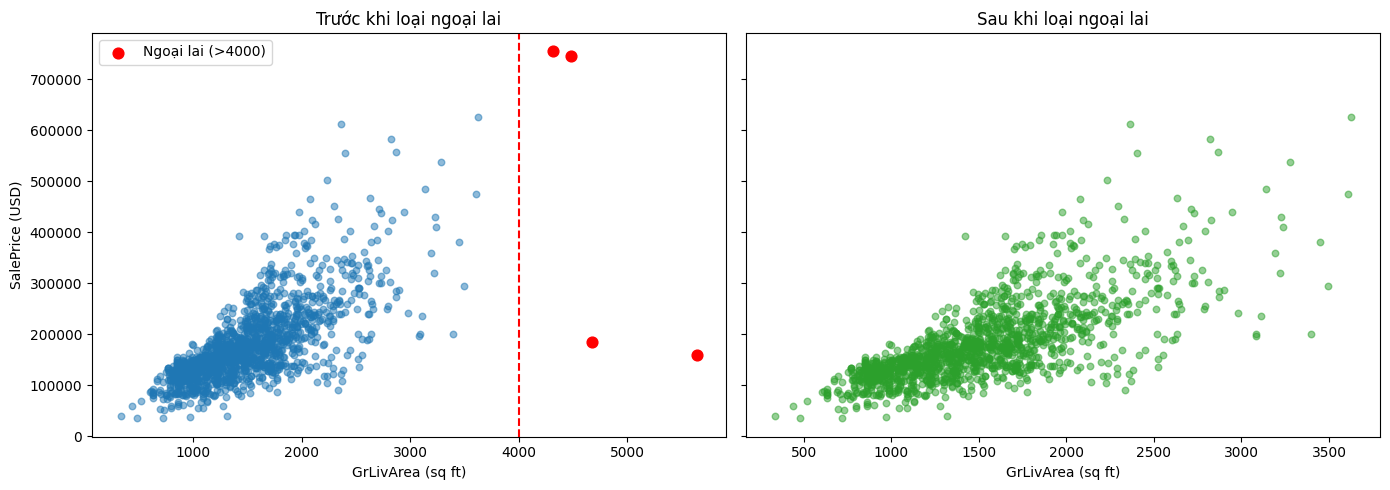

In [4]:
mask_out = df["GrLivArea"] > 4000
print("Các mẫu ngoại lai bị loại:")
print(df.loc[mask_out, ["Id", "GrLivArea", "SalePrice", "SaleCondition"]])

df_clean = df.loc[~mask_out].reset_index(drop=True)
print("Kích thước trước/sau:", df.shape, "->", df_clean.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax[0].scatter(df["GrLivArea"], df["SalePrice"], alpha=.5, s=22, color="#1f77b4")
ax[0].scatter(df.loc[mask_out, "GrLivArea"], df.loc[mask_out, "SalePrice"], color="red", s=60, label="Ngoại lai (>4000)")
ax[0].axvline(4000, color="red", linestyle="--"); ax[0].legend(); ax[0].set_title("Trước khi loại ngoại lai")
ax[1].scatter(df_clean["GrLivArea"], df_clean["SalePrice"], alpha=.5, s=22, color="#2ca02c")
ax[1].set_title("Sau khi loại ngoại lai")
for a in ax: a.set_xlabel("GrLivArea (sq ft)")
ax[0].set_ylabel("SalePrice (USD)")
save("hinh4_outlier")

## 5. Làm sạch: loại cột, giá trị thiếu, mã hóa thứ bậc

In [5]:
# 5.1 Loại cột: Id, SalePrice và cột thiếu > 80%
miss_ratio = df_clean.isna().mean()
drop_missing = miss_ratio[miss_ratio > 0.8].index.tolist()
print("Cột thiếu > 80% bị loại:", drop_missing, miss_ratio[drop_missing].round(4).to_dict())

y_raw = df_clean["SalePrice"]
y = np.log1p(y_raw)
X = df_clean.drop(columns=["Id", "SalePrice"] + drop_missing)
print("Số đặc trưng còn lại:", X.shape[1])

# 5.2 NaN mang nghĩa "không có" -> điền "None" (theo mô tả dữ liệu).
# Lưu ý: MasVnrType có hạng mục "None" (không ốp tường) nhưng pandas đọc thành NaN.
none_cols = ["BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2",
             "FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","MasVnrType"]
none_cols = [c for c in none_cols if c in X.columns]
print("\nSố NaN 'không có' sẽ điền None:\n", X[none_cols].isna().sum())
X[none_cols] = X[none_cols].fillna("None")

# 5.3 Mã hóa thứ bậc cho biến chất lượng
qual_map = {"None":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5}
qual_cols = ["ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC",
             "KitchenQual","FireplaceQu","GarageQual","GarageCond"]
qual_cols = [c for c in qual_cols if c in X.columns]
for c in qual_cols:
    X[c] = X[c].map(qual_map)
print("\nĐã mã hóa thứ bậc:", qual_cols)

# 5.4 MSSubClass là mã loại nhà -> biến phân loại
X["MSSubClass"] = X["MSSubClass"].astype(str)

print("\nSố NaN còn lại cần impute trong pipeline (thiếu thật):")
left = X.isna().sum(); print(left[left > 0])

Cột thiếu > 80% bị loại: ['Alley', 'PoolQC', 'Fence', 'MiscFeature'] {'Alley': 0.9375, 'PoolQC': 0.9966, 'Fence': 0.8077, 'MiscFeature': 0.9629}
Số đặc trưng còn lại: 75

Số NaN 'không có' sẽ điền None:
 BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
FireplaceQu     690
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
MasVnrType      871
dtype: int64

Đã mã hóa thứ bậc: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

Số NaN còn lại cần impute trong pipeline (thiếu thật):
LotFrontage    259
MasVnrArea       8
Electrical       1
GarageYrBlt     81
dtype: int64


## 6. Chia Train/Validation & Pipeline (impute + scale + one-hot)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

Xtr, Xval, ytr, yval, ytr_raw, yval_raw = train_test_split(
    X, y, y_raw, test_size=0.2, random_state=42)
print("Train:", Xtr.shape, "| Validation:", Xval.shape)

numeric_cols = Xtr.select_dtypes(include=np.number).columns.tolist()
categorical_cols = Xtr.select_dtypes(exclude=np.number).columns.tolist()
print("Số cột số:", len(numeric_cols), "| Số cột phân loại:", len(categorical_cols))

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_cols),
])

A_train = preprocessor.fit_transform(Xtr).astype("float32")   # chỉ fit trên Train
B_val   = preprocessor.transform(Xval).astype("float32")
feature_names = preprocessor.get_feature_names_out()

print("Ma trận đặc trưng: Train", A_train.shape, "| Val", B_val.shape)
print("NaN còn lại:", int(np.isnan(A_train).sum()), int(np.isnan(B_val).sum()))
print("Số đặc trưng One-Hot sinh ra:", len(feature_names) - len(numeric_cols))

Train: (1164, 75) | Validation: (292, 75)
Số cột số: 44 | Số cột phân loại: 31
Ma trận đặc trưng: Train (1164, 258) | Val (292, 258)
NaN còn lại: 0 0
Số đặc trưng One-Hot sinh ra: 214


## 7. Minh họa chuẩn hóa (Hình 5) & lưu dữ liệu dùng chung

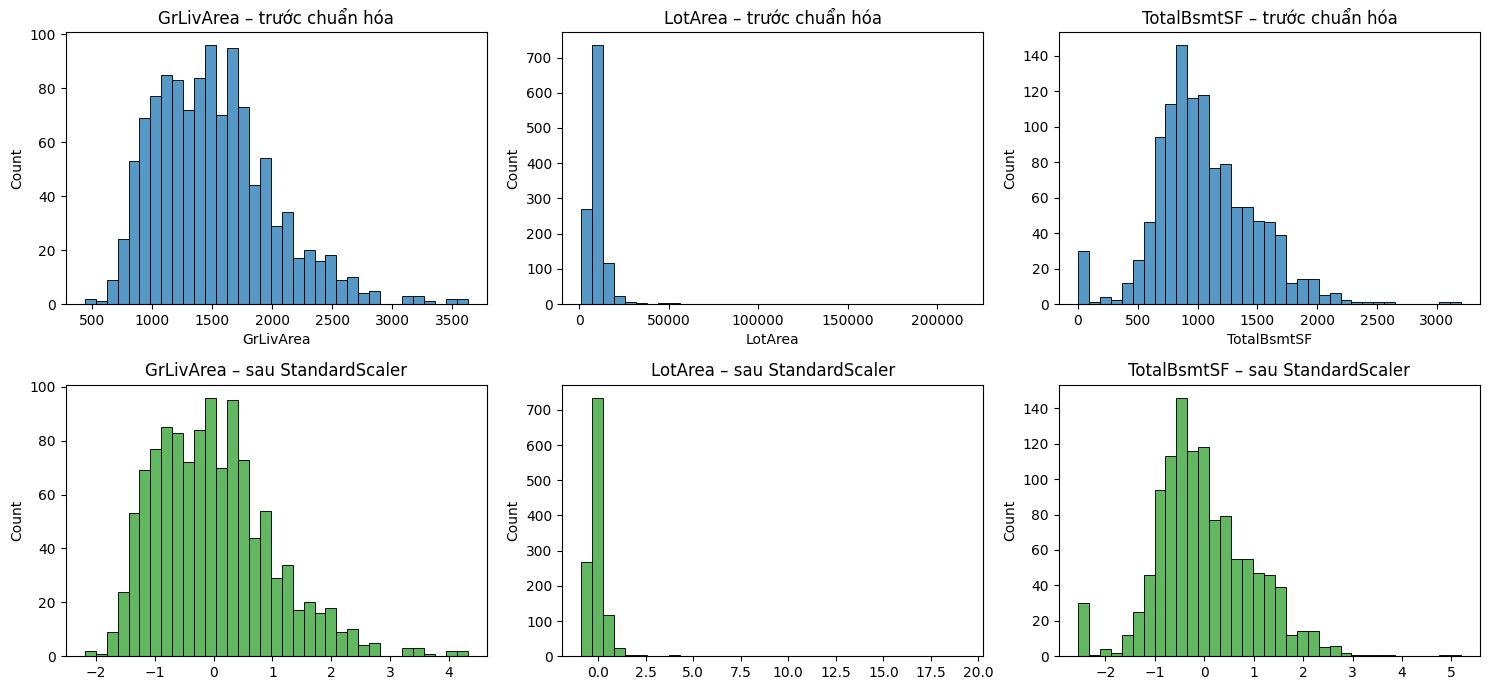

Đã lưu vào thư mục processed/


In [7]:
cols_show = ["GrLivArea", "LotArea", "TotalBsmtSF"]
idx = [list(feature_names).index(f"num__{c}") for c in cols_show]
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for j, c in enumerate(cols_show):
    sns.histplot(Xtr[c].dropna(), bins=35, ax=ax[0, j], color="#1f77b4"); ax[0, j].set_title(f"{c} – trước chuẩn hóa")
    sns.histplot(A_train[:, idx[j]], bins=35, ax=ax[1, j], color="#2ca02c"); ax[1, j].set_title(f"{c} – sau StandardScaler")
save("hinh5_scaling")

import joblib
joblib.dump(preprocessor, "processed/preprocessor.joblib")
pd.DataFrame(A_train, columns=feature_names).assign(target=ytr.values).to_csv("processed/train_processed.csv", index=False)
pd.DataFrame(B_val, columns=feature_names).assign(target=yval.values).to_csv("processed/val_processed.csv", index=False)
print("Đã lưu vào thư mục processed/")

## 8. Bảng tổng kết trước/sau

In [8]:
summary = pd.DataFrame({
    "Chỉ tiêu": ["Số dòng train", "Số cột", "Cột có NaN", "Biến phân loại dạng chữ", "Skew biến mục tiêu"],
    "Trước": [df.shape[0], df.shape[1], int((df.isna().sum() > 0).sum()),
              int(df.select_dtypes(exclude=np.number).shape[1]), round(df["SalePrice"].skew(), 4)],
    "Sau": [f"{len(Xtr)+len(Xval)} ({len(Xtr)} train + {len(Xval)} val)", A_train.shape[1],
            int(np.isnan(A_train).sum()), 0, round(y.skew(), 4)],
})
print(summary.to_string(index=False))

               Chỉ tiêu     Trước                         Sau
          Số dòng train 1460.0000 1456 (1164 train + 292 val)
                 Số cột   81.0000                         258
             Cột có NaN   19.0000                           0
Biến phân loại dạng chữ   43.0000                           0
     Skew biến mục tiêu    1.8829                      0.0655
